In [1]:
import os
import pandas as pd

df = pd.read_csv("classified_conversations.csv")

df.head()

,conversation,intent,objections,product_category,engagement_level
0,"Customer: Hi, Im interested in purchasing a ne...",Customer is looking for a product or service t...,"Pricing concerns, trust issues, and skepticism...",Multiple categories,warm
1,"Customer: Hi, Im interested in learning more a...",Customer is seeking a solution to a specific h...,Skepticism about the product's effectiveness a...,Health Product,warm
2,"Customer: Hi, Im interested in investing in th...",Customer is looking for a trustworthy financia...,Trust issues due to past experiences with othe...,Financial Service,hot
3,"Customer: Hello, Im interested in your financi...",Customer is seeking a financial advisor who ca...,Concerns about affordability and trust issues ...,Financial Planning,warm
4,"Customer: Hi, Im interested in purchasing a ne...",Customer is looking for a product or service t...,"Budget constraints, and uncertainty about the ...",Multiple categories,warm


[Text(0, 0, '636'), Text(0, 0, '133'), Text(0, 0, '77')]

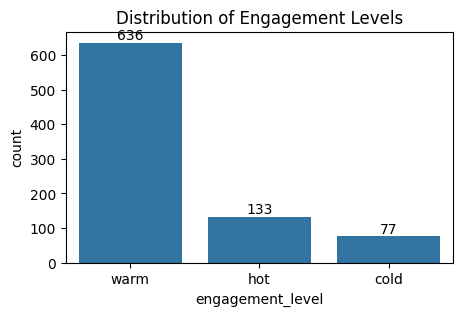

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df.value_counts("engagement_level")

plt.figure(figsize=(5, 3))
sns.countplot(x="engagement_level", data=df, order=df["engagement_level"].value_counts().index)
plt.title("Distribution of Engagement Levels")
plt.bar_label(plt.gca().containers[0])

In [ ]:
import sys
sys.path.insert(0, ".")

from configs.sales import sales_config
from pipeline.clustering import ClusteringPipeline, ClusteringConfig

clustering = ClusteringPipeline(config=sales_config)
df = clustering.run(df)

In [ ]:
cluster_col = "objection_cluster"
counts = df[cluster_col].value_counts().sort_index()
print(f"Clusters found: {int(df[cluster_col].max()) + 1}")
print(counts)

In [ ]:
pd.set_option('display.max_colwidth', None)
df[df["objection_cluster"] == 2]["objections"].head(20)

In [ ]:
import numpy as np

cluster_col = "objection_cluster"
cluster_ids = sorted(df[cluster_col].dropna().unique())

for cluster_id in cluster_ids:
    if cluster_id == -1:
        continue
    unique_objections = df[df[cluster_col] == cluster_id]["objections"].unique()
    sample = np.random.choice(unique_objections, size=min(20, len(unique_objections)), replace=False)
    print(f"Cluster {int(cluster_id)} sample:")
    for obj in sample:
        print(f"  - {obj}")
    print()